# 02 光谱诊断与手动调参

这个 notebook 是当前主要的数据处理和调参入口，形式接近旧版 `legacy/spectral_diagnostics.ipynb`：先集中设置参数，再读取光谱、测量科学量、逐项画图，最后提供单条谱线的局部检查图。

批量读谱、谱线库、平滑、连续谱和质检规则主要调用 `src.spectral_pipeline`。Notebook 里保留的是方便手动调整的包装函数和可视化函数。

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from importlib import reload

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src import spectral_pipeline as sp
from src import spectral_notebook_tools as snt

ANALYSIS_DIR = PROJECT_ROOT / "output" / "analysis_pipeline"
FIG_DIR = ANALYSIS_DIR / "figures"

## 1. 配置和调参位置

常用调参只改这个 cell：

- `TARGETS`：空列表表示处理所有 `data/SN*/` 光谱。
- `TARGET_METADATA`：只放你手动确认的信息；红移默认来自 `data/tns_public_objects.csv`，这里只作为缺失字段的补充。
- `TARGET_LINES`：为某个目标手动覆盖要测的谱线；留空时按 SN 类型自动选择关键谱线。
- `AUTO_CLASSIFY_TYPES`：没有手动类型时，使用本地光谱经验粗分类结果给 02 自动选线。
- `LINE_PARAM_OVERRIDES`：按谱线、目标+谱线、目标+文件+谱线覆盖半宽、平滑窗口、连续谱边缘比例。
- `OUTPUT_TAG`：空字符串时自动使用当前目标名；`SAVE_PRODUCTS=True`/`SAVE_FIGURES=True` 只会覆盖同一 tag 的输出，不会覆盖其他目标的输出。
- `CHECK_LINE_KEY=None` 时，单条谱线局部检查会先显示可选关键线表，再用 `CHECK_LINE_INDEX` 选第几条线。
- `CHECK_HALF_WIDTH`、`CHECK_SMOOTH_WINDOW`、`CHECK_EDGE_FRACTION` 只影响单条谱线局部检查图，不会改批量产物，除非你把同样参数写回 `LINE_PARAM_OVERRIDES` 并重新跑第 6 节。
- `CHECK_*`：控制最后的单条谱线局部检查图。

相位说明：当前 TNS 公共目录只有 `discoverydate`，没有 maximum-light / peak-date 字段；本 notebook 的 `phase_days` 始终是距发现日天数。不要把它写成相对最大光相位，除非后续新增可靠光变曲线峰值日期并单独增加新列。

方法说明：本节只设置参数，不读取数据，也不运行任何拟合。


In [2]:
TARGETS = []  # 例如 ["SN2026KID"]; 空列表表示全部目标

TARGET_METADATA = {
    # 只填自己确认的信息；不要从 data/tns_public_objects.csv 复制。
    # "SN2026KID": {"type": "SN II", "discoverydate": "2026-04-22 00:00:00"},
}

TARGET_LINES = {
    # 最终报告采用更保守的线表；不稳定或强混合的线保留在诊断图中人工参考，不进入 adopted 表。
    "SN2026FVX": ["CaIIHK", "SiII6355"],
    "SN2026JLM": ["CaIIHK", "SiII6355"],
    "SN2026KID": ["FeII5169"],
    "SN2026KIE": ["CaIIHK", "CaIINIR", "OI7774"],
    # LMP 缺少 TNS 红移，全部候选线只用于定性检查，QC 不会自动采用其速度。
    "SN2026LMP": ["Halpha", "Hbeta", "HeI5876", "HeI6678", "HeI7065", "FeII5169", "CaIIHK", "CaIINIR"],
}

AUTO_CLASSIFY_TYPES = True  # 没有手动 type 时，用本地光谱经验粗分类来自动选线
AUTO_APPLY_ROUGH_Z = False  # 红移默认采用 TNS public catalog；不默认采用粗分类红移
AUTO_OVERWRITE_MANUAL_TYPE = False

LINE_HALF_WIDTH = 420.0
LINE_SMOOTH_WINDOW = 21
LINE_EDGE_FRACTION = 0.18
BB_WAVE_RANGE = (4200.0, 7600.0)
RAW_REFERENCE_LINES = ["CaIIHK", "Hgamma", "Hbeta", "FeII5169", "SII5640", "HeI5876", "SiII6355", "Halpha", "OI7774", "CaIINIR"]

LINE_PARAM_OVERRIDES = {
    # "SiII6355": {"half_width": 500.0},
    # ("SN2026KID", "Halpha"): {"half_width": 650.0, "smooth_window": 31},
    # ("SN2026JLM", "SN2026jlm_bfosc_20260510.fits", "SiII6355"): {"edge_fraction": 0.22},
}

SAVE_PRODUCTS = True  # 写出 CSV；同一 RUN_TAG 会覆盖，自动目标 tag 不会覆盖别的目标
SAVE_FIGURES = True  # 写出 PNG；同一 RUN_TAG 会覆盖，自动目标 tag 不会覆盖别的目标
PRODUCT_PREFIX = ""  # 例如 "trial" 可在目标 tag 前再加一层前缀
OUTPUT_TAG = "final5"  # 空字符串表示自动用当前目标名，例如 SN2026KID；也可手动填 "trial_SN2026KID"

DIAGNOSTIC_TARGET = None  # 图形诊断网格只看某个目标；None 表示全部
MAX_DIAGNOSTIC_PANELS = 12


### 按 SN 类型自动选择的关键科学谱线

这些谱线来自当前 `src.spectral_pipeline` 的默认规则，并参考了文献调研中 SNID/Superfit/DASH 分类、Type II 光谱多样性、Ia 大样本和去包层超新星数据集的常用诊断。自动测量线表会比最终 adopted 线表更宽，目的是保留检查痕迹；正式引用仍以 `qc_flag=adopt` 和人工检查为准。

| 类型 | 自动测量的关键谱线 | 自动 adopted 策略 |
|---|---|---|
| Ia | Si II 6355/5972, S II 5640, Ca II H&K/NIR, C II 6580 | 默认只把 Si II 6355 和 Ca II blend proxy 作为可 adopted 主线；Si II 5972 保留为 visual/check context。 |
| II | H alpha/beta/gamma, Fe II 5169/5018/4924, Sc II 5527, Ca II H&K/NIR | 默认只把 Fe II 5169 作为可 adopted 速度量级；Balmer trough 受 P-Cygni 发射结构影响，保留为 visual/check context。 |
| IIn | H alpha/beta/gamma, Fe II 5169, Ca II H&K | IIn 的 Balmer 发射/相互作用迹象需要人工看图确认。 |
| IIb | H alpha/beta, He I 5876/6678/7065, Fe II 5169, Ca II H&K/NIR | 默认只把 Fe II 5169 作为可 adopted 速度量级；H/He 线用于子型检查。 |
| Ib | He I 5876/6678/7065, Ca II H&K/NIR, O I 7774 | 氦线识别和 Ib/Ic 区分需要结合模板和局部图。 |
| Ic/Ic-BL | O I 7774, Ca II H&K/NIR, Fe II 5169, C II 6580 | 无氢氦谱线、O/Ca/Fe 速度与宽线候选检查。 |

Ca II H&K 与 Ca II NIR 是混合线代理测量，输出表会用 `rest_wave_choice` 和 `line_blend_note` 标明所用代理静止波长。`TARGET_LINES` 留空时会按这些规则自动选择；若某个目标需要更保守或更窄的线表，可以在配置区手动覆盖。


## 2. 导入 notebook 工具函数

大段调参辅助函数已经放到 `src/spectral_notebook_tools.py`，这里保持 notebook 简洁。你修改 `src/` 后可以重新运行这个 cell。

方法说明：本节只导入/重载函数，不运行任何拟合。

In [3]:
reload(snt)
print("Loaded src.spectral_notebook_tools")

Loaded src.spectral_notebook_tools


## 3. 读取本地观测光谱

这里只读取 `data/` 下的一维 FITS 光谱，同时自动合并 `data/tns_public_objects.csv` 里的 `z/type/discoverydate/host` 信息。`TARGET_METADATA` 只用于补充缺失字段；如果 TNS catalog 没有红移，才退回到这里手动填的 `z`。

方法说明：本步不做物理拟合，也不做红移校正；图中光谱只用 Savitzky-Golay 作轻微预平滑以便显示。Savitzky-Golay 的含义是在移动窗口内做低阶多项式拟合，并用该窗口中心的拟合值替代原始值。竖虚线是 `RAW_REFERENCE_LINES` 的未校准静止波长参考线，直接画在观测波长轴上，没有乘 `(1+z)`，只用于找线。

,target,file,date_obs,phase_days,type,z,host,n_pix,wave_min,wave_max,flux_median,exptime,instrument,setup
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,,1861,3738.479958,8877.439763,4.921472e-16,3000.0,BFOSC,slit23_385LP_NewG4
1,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260326.fits,2026-03-26 16:21:28,8.695464,SN Ia,0.004846,,1861,3741.100590,8870.579225,6.050648e-15,1800.0,BFOSC,slit23_385LP_NewG4
2,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260407.fits,2026-04-07 16:57:15,20.720314,SN Ia,0.004846,,1861,3741.687801,8869.478126,1.808225e-14,1500.0,BFOSC,slit23_385LP_NewG4
3,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260508.fits,2026-05-08 14:38:31,51.623971,SN Ia,0.004846,,1861,3735.483487,8864.023490,3.132086e-15,2100.0,BFOSC,slit23_385LP_NewG4
4,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260426.fits,2026-04-26 12:52:13,14.511922,SN Ia,0.016738,,1861,3727.944351,8857.385099,7.789561e-15,2400.0,BFOSC,slit23_385LP_NewG4
5,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260504.fits,2026-05-04 12:29:41,22.496273,SN Ia,0.016738,,1861,3734.330873,8863.754118,1.308646e-15,3000.0,BFOSC,slit23_385LP_NewG4
6,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260508.fits,2026-05-08 15:28:02,26.620128,SN Ia,0.016738,,1861,3735.483487,8864.023490,1.507618e-15,3000.0,BFOSC,slit23_385LP_NewG4
7,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,3.971331,SN II,0.001700,,1861,3727.929497,8857.409114,7.767351e-15,2400.0,BFOSC,slit23_385LP_NewG4
8,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,5.028935,SN II,0.001700,,1861,3728.500379,8859.653799,1.450921e-15,1500.0,BFOSC,slit23_385LP_NewG4
9,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,2026-05-08 16:27:20,16.085799,SN II,0.001700,,1861,3735.483487,8864.023490,1.801202e-15,3000.0,BFOSC,slit23_385LP_NewG4


z_source 说明：tns_public_catalog=来自 data/tns_public_objects.csv；manual_config_fallback=TNS 缺失时来自 TARGET_METADATA；unset=未设置。
未处理的多历元光谱序列图：只用原始观测波长和本地 FITS flux，不应用红移、类型或自动选线。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/raw_spectral_sequence_SN2026FVX.png


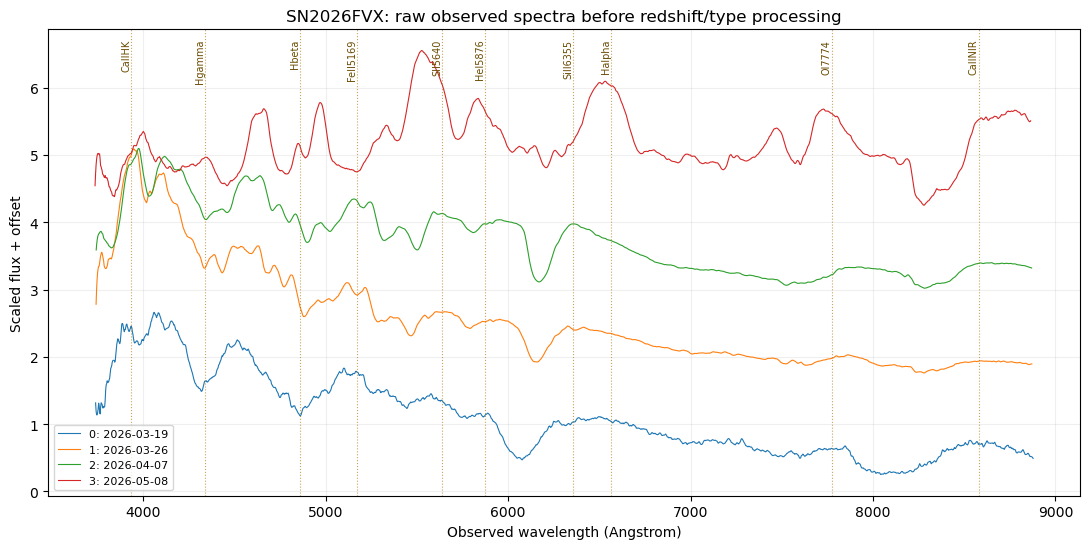

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/raw_spectral_sequence_SN2026JLM.png


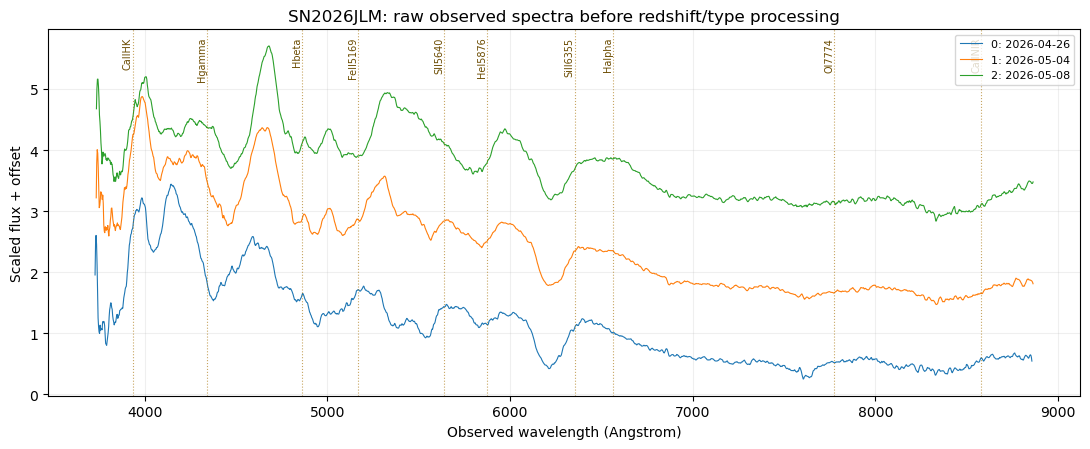

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/raw_spectral_sequence_SN2026KID.png


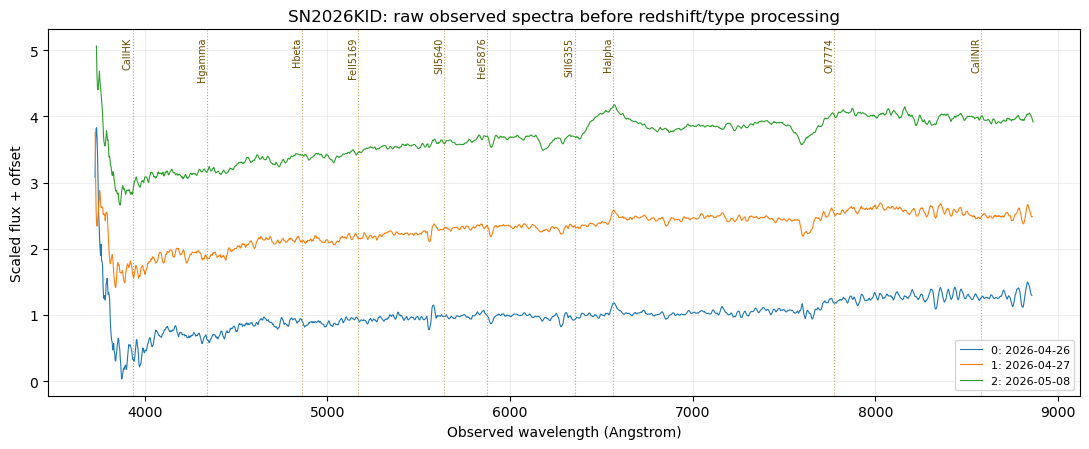

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/raw_spectral_sequence_SN2026KIE.png


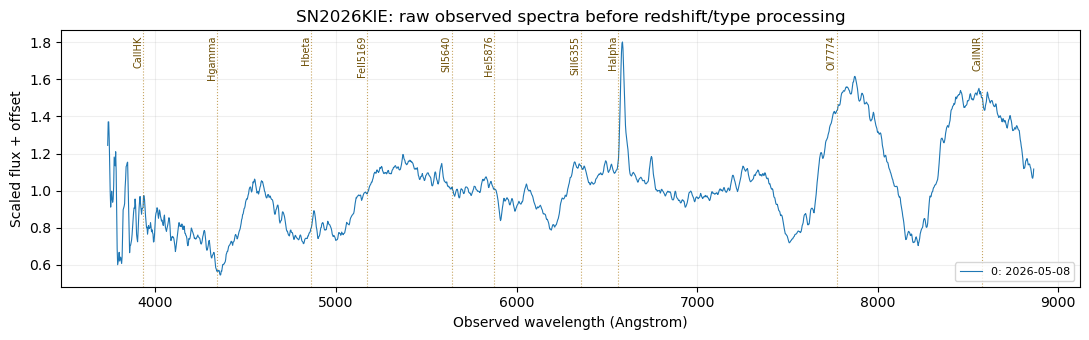

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/raw_spectral_sequence_SN2026LMP.png


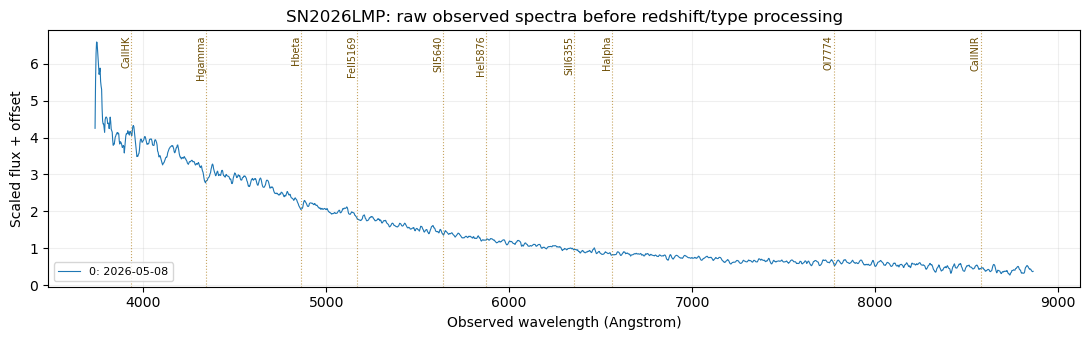

In [4]:
spectra_raw, skipped_fits = snt.load_observed_spectra(PROJECT_ROOT, TARGET_METADATA)
if TARGETS:
    wanted = {snt.target_key(t) for t in TARGETS}
    spectra_raw = [spec for spec in spectra_raw if spec["target"] in wanted]

if not spectra_raw:
    raise RuntimeError("没有找到可处理的一维 FITS 光谱。请检查 data/SN*/ 下的文件。")

summary_raw = sp.build_summary(spectra_raw)
display(summary_raw)
print("z_source 说明：tns_public_catalog=来自 data/tns_public_objects.csv；manual_config_fallback=TNS 缺失时来自 TARGET_METADATA；unset=未设置。")
if not skipped_fits.empty:
    print("跳过的 FITS：")
    display(skipped_fits)

print("未处理的多历元光谱序列图：只用原始观测波长和本地 FITS flux，不应用红移、类型或自动选线。")
for target in sorted(summary_raw["target"].unique()):
    raw_sequence_fig = snt.plot_raw_spectral_sequence(
        target,
        spectra_raw,
        fig_dir=FIG_DIR,
        save_figures=SAVE_FIGURES,
        reference_lines=RAW_REFERENCE_LINES,
    )
    snt.show_figure(raw_sequence_fig)

## 4. 采用 TNS 红移并用本地光谱粗分类自动选线

方法说明：本节不做任何新的红移拟合。每条谱的 `z` 直接从 `data/tns_public_objects.csv` 读取，`TARGET_METADATA` 只补充缺失字段。后面的粗分类只负责整理本地光谱的类型建议和自动选线，不会覆盖 TNS 红移。

In [5]:
analysis_context_table = pd.DataFrame(
    [
        {
            "target": spec["target"],
            "file": spec["file"],
            "z": spec.get("z", np.nan),
            "z_source": spec.get("z_source", "unset"),
        }
        for spec in spectra_raw
    ]
)
display(analysis_context_table)

spectra = [dict(spec) for spec in spectra_raw]

rough_spectrum_table, rough_target_table, rough_feature_table = snt.rough_classify_spectra(spectra)
template_spectrum_table, template_target_table = snt.summarize_local_template_classifications(PROJECT_ROOT)
active_targets = {spec["target"] for spec in spectra}
if not template_target_table.empty:
    template_target_table = template_target_table[template_target_table["target"].isin(active_targets)].reset_index(drop=True)
if not template_spectrum_table.empty:
    template_spectrum_table = template_spectrum_table[template_spectrum_table["target"].isin(active_targets)].reset_index(drop=True)
classification_target_table = snt.combine_template_and_rough_classifications(template_target_table, rough_target_table)
if AUTO_CLASSIFY_TYPES:
    spectra = snt.apply_classification_context_to_spectra(
        spectra,
        classification_target_table,
        apply_type=True,
        apply_z=AUTO_APPLY_ROUGH_Z,
        overwrite_existing_type=AUTO_OVERWRITE_MANUAL_TYPE,
    )

summary = sp.build_summary(spectra)
display(summary)
display(classification_target_table)
display(template_target_table)
display(rough_target_table)
display(snt.selected_line_plan(spectra, TARGET_LINES))

RUN_TAG = snt.analysis_output_tag(summary[["target"]], OUTPUT_TAG)
print(f"analysis output tag = {RUN_TAG}")

,target,file,z,z_source
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,0.004846,tns_public_catalog
1,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260326.fits,0.004846,tns_public_catalog
2,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260407.fits,0.004846,tns_public_catalog
3,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260508.fits,0.004846,tns_public_catalog
4,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260426.fits,0.016738,tns_public_catalog
5,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260504.fits,0.016738,tns_public_catalog
6,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260508.fits,0.016738,tns_public_catalog
7,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,0.001700,tns_public_catalog
8,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,0.001700,tns_public_catalog
9,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,0.001700,tns_public_catalog


,target,file,date_obs,phase_days,type,z,host,n_pix,wave_min,wave_max,flux_median,exptime,instrument,setup
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,,1861,3738.479958,8877.439763,4.921472e-16,3000.0,BFOSC,slit23_385LP_NewG4
1,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260326.fits,2026-03-26 16:21:28,8.695464,SN Ia,0.004846,,1861,3741.100590,8870.579225,6.050648e-15,1800.0,BFOSC,slit23_385LP_NewG4
2,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260407.fits,2026-04-07 16:57:15,20.720314,SN Ia,0.004846,,1861,3741.687801,8869.478126,1.808225e-14,1500.0,BFOSC,slit23_385LP_NewG4
3,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260508.fits,2026-05-08 14:38:31,51.623971,SN Ia,0.004846,,1861,3735.483487,8864.023490,3.132086e-15,2100.0,BFOSC,slit23_385LP_NewG4
4,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260426.fits,2026-04-26 12:52:13,14.511922,SN Ia,0.016738,,1861,3727.944351,8857.385099,7.789561e-15,2400.0,BFOSC,slit23_385LP_NewG4
5,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260504.fits,2026-05-04 12:29:41,22.496273,SN Ia,0.016738,,1861,3734.330873,8863.754118,1.308646e-15,3000.0,BFOSC,slit23_385LP_NewG4
6,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260508.fits,2026-05-08 15:28:02,26.620128,SN Ia,0.016738,,1861,3735.483487,8864.023490,1.507618e-15,3000.0,BFOSC,slit23_385LP_NewG4
7,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,3.971331,SN II,0.001700,,1861,3727.929497,8857.409114,7.767351e-15,2400.0,BFOSC,slit23_385LP_NewG4
8,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,5.028935,SN II,0.001700,,1861,3728.500379,8859.653799,1.450921e-15,1500.0,BFOSC,slit23_385LP_NewG4
9,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,2026-05-08 16:27:20,16.085799,SN II,0.001700,,1861,3735.483487,8864.023490,1.801202e-15,3000.0,BFOSC,slit23_385LP_NewG4


,target,adopted_type,type_source,type_confidence,template_type,rough_type,template_z_median,rough_z_median,selected_lines
0,SN2026FVX,SN Ia,local_template:Superfit,1.0,SN Ia,Unclassified,0.005,0.065250,"SiII6355, SiII5972, SII5640, CaIIHK, CaIINIR, ..."
1,SN2026JLM,SN Ia,local_template:Superfit,1.0,SN Ia,Unclassified,0.015,0.016738,"SiII6355, SiII5972, SII5640, CaIIHK, CaIINIR, ..."
2,SN2026KID,SN II,local_template:Superfit,1.0,SN II,Unclassified,0.000,0.002000,"Halpha, Hbeta, Hgamma, FeII5169, FeII5018, FeI..."
3,SN2026KIE,SN Ic,local_template:Superfit,1.0,SN Ic,Unclassified,0.000,0.003000,"OI7774, CaIIHK, CaIINIR, FeII5169, CII6580"
4,SN2026LMP,SN IIb,local_template:Superfit,1.0,SN IIb,Unclassified,0.010,0.048000,"Halpha, Hbeta, HeI5876, HeI6678, HeI7065, FeII..."


,target,template_type,template_type_confidence,template_z_median,n_template_results,template_votes,method
0,SN2026FVX,SN Ia,1.0,0.005,4,SN Ia:7.09,Superfit
1,SN2026JLM,SN Ia,1.0,0.015,3,SN Ia:5.01,Superfit
2,SN2026KID,SN II,1.0,0.000,3,SN II:0.88,Superfit
3,SN2026KIE,SN Ic,1.0,0.000,1,SN Ic:1.27,Superfit
4,SN2026LMP,SN IIb,1.0,0.010,1,SN IIb:0.34,Superfit


,target,rough_type,rough_type_confidence,n_spectra,rough_z_median,rough_z_scatter,rough_velocity_median_kms,type_votes,selected_lines
0,SN2026FVX,Unclassified,0.292604,4,0.065250,0.020658,9193.231347,Unclassified:0.88; SN II:0.40,"Halpha, Hbeta, SiII6355, HeI5876, OI7774, CaII..."
1,SN2026JLM,Unclassified,0.320244,3,0.016738,0.018131,11410.236012,Unclassified:0.64; SN II:0.36,"Halpha, Hbeta, SiII6355, HeI5876, OI7774, CaII..."
2,SN2026KID,Unclassified,0.310615,3,0.002000,0.039694,4875.246347,Unclassified:0.93,"Halpha, Hbeta, SiII6355, HeI5876, OI7774, CaII..."
3,SN2026KIE,Unclassified,0.162345,1,0.003000,NaN,10930.161103,Unclassified:0.16,"Halpha, Hbeta, SiII6355, HeI5876, OI7774, CaII..."
4,SN2026LMP,Unclassified,0.250693,1,0.048000,NaN,8640.128796,Unclassified:0.25,"Halpha, Hbeta, SiII6355, HeI5876, OI7774, CaII..."


,target,type,type_source,selected_lines
0,SN2026FVX,SN Ia,,"CaIIHK, SiII6355"
1,SN2026JLM,SN Ia,,"CaIIHK, SiII6355"
2,SN2026KID,SN II,,FeII5169
3,SN2026KIE,SN Ic,,"CaIIHK, CaIINIR, OI7774"
4,SN2026LMP,SN IIb,local_template:Superfit,"Halpha, Hbeta, HeI5876, HeI6678, HeI7065, FeII..."


analysis output tag = final5


## 5. 多历元光谱序列

下轴是观测波长，上轴是按当前目标红移换算后的静止系波长。谱线竖线画在观测波长位置，即 `rest_wave * (1 + z)`；如果目标还没有红移，就只能暂时画在静止波长位置。

方法说明：本步只是可视化，没有额外拟合；光谱为显示目的用 Savitzky-Golay 平滑和中位数尺度归一，谱线位置只由上面采用的 TNS 红移换算。

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/spectral_sequence_SN2026FVX.png


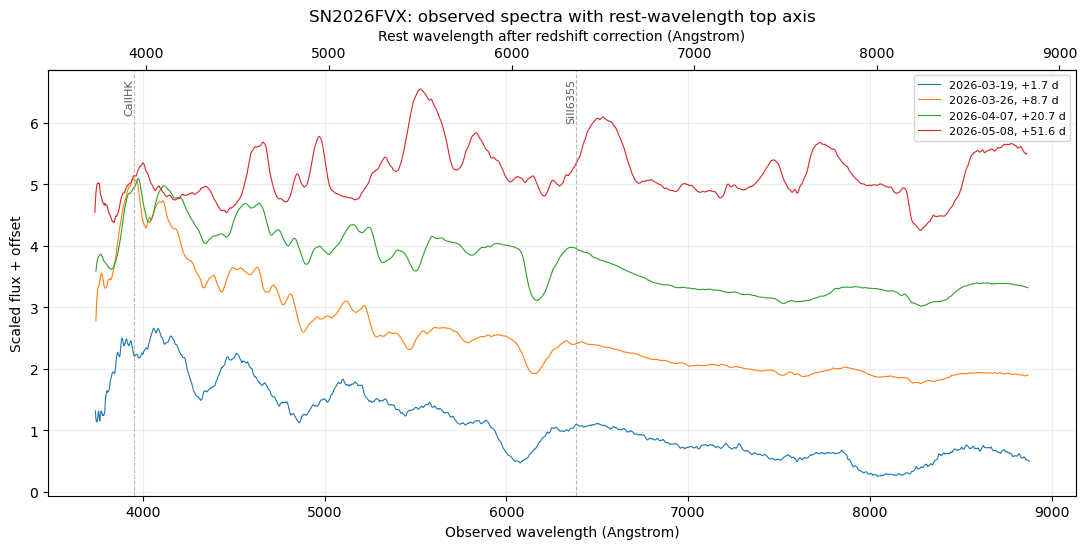

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/spectral_sequence_SN2026JLM.png


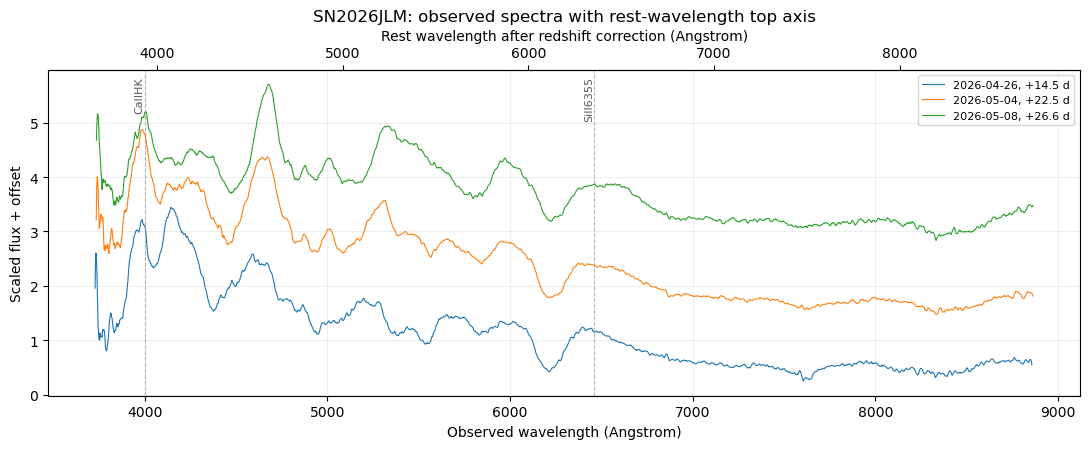

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/spectral_sequence_SN2026KID.png


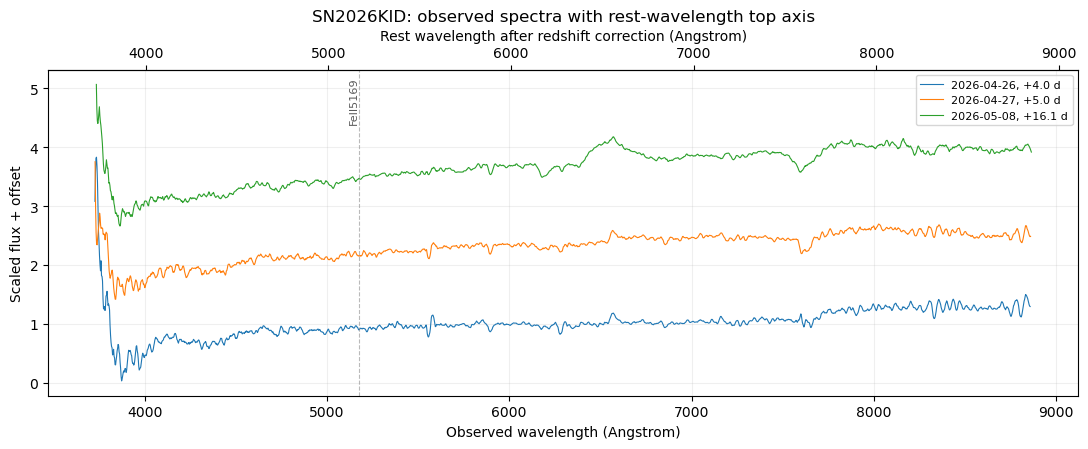

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/spectral_sequence_SN2026KIE.png


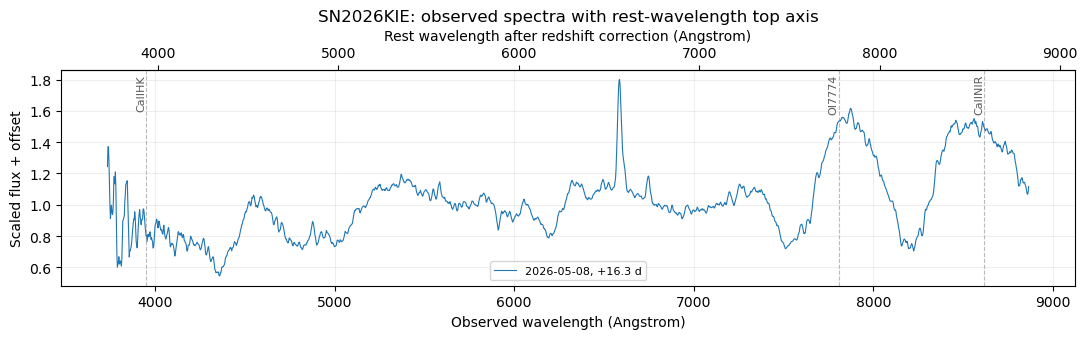

saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/spectral_sequence_SN2026LMP.png


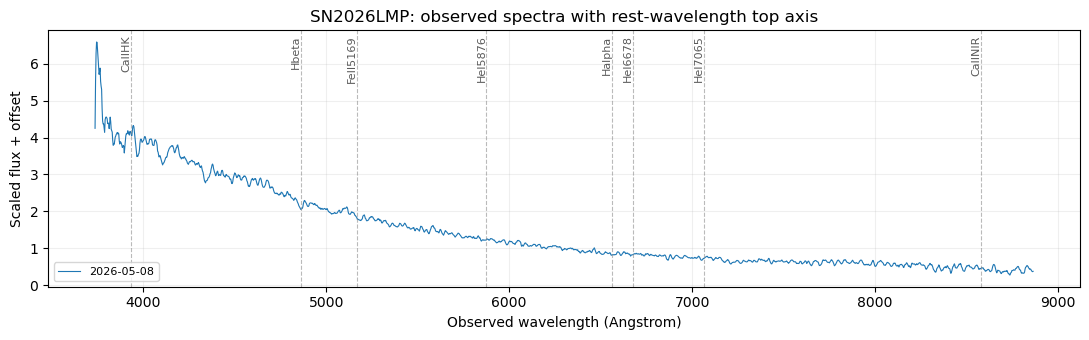

In [6]:
for target in sorted(summary["target"].unique()):
    sequence_fig = snt.plot_spectral_sequence_dual_axis(
        target,
        spectra,
        target_lines=TARGET_LINES,
        fig_dir=FIG_DIR,
        save_figures=SAVE_FIGURES,
    )
    snt.show_figure(sequence_fig)

## 6. 批量测量谱线、黑体颜色温度和宿主线

这一步使用上面采用的 TNS 红移。如果某个目标还没有红移，速度和静止系谱线测量只是占位结果，不应写入科学结论。这里的 `phase_days` 是距 TNS 发现日天数，不是相对最大光相位。

实际测量的谱线由前面生成的 `selected_line_plan` 决定：`TARGET_LINES` 有手动覆盖时优先用它，否则按手动类型或自动粗分类类型选择关键谱线。

方法说明：谱线测量先转到当前静止系，再用 Savitzky-Golay 移动窗口低阶多项式预平滑，并用局部线性连续谱归一化；随后直接在归一化谱的搜索窗口内寻找最低点。最终的吸收中心 `abs_wave`、速度 `velocity_kms` 和线深 `depth` 都来自这个最低点，`FWHM_A` 来自最低点两侧的半深度交点宽度。pEW 仍由 `1 - flux/continuum` 的正面积直接积分，不使用任何解析轮廓面积。黑体颜色温度用 Planck 黑体谱做非线性最小二乘拟合。宿主线指标用局部中位数连续谱和 robust noise，不做轮廓模型拟合。

误差、系统散布和质检说明：

- `fit_center_err_A` 是最低点波长的形式不确定度：程序用 `raw_norm - norm` 的局部残差估计噪声，并结合局部波长采样，统计最低点附近在噪声阈值内不可区分的像素范围；如果最低点太贴边、噪声无法估计或可用像素太少，对应误差会是 `NaN`。
- 速度用 `velocity_kms = c * (rest_wave - abs_wave) / rest_wave` 计算，其中 `abs_wave` 是吸收最低点。因此速度误差只从最低点波长误差传播：`velocity_err_kms = c * fit_center_err_A / rest_wave`。
- `velocity_sys_kms`、`pEW_sys_A`、`FWHM_sys_A` 是改变平滑窗口和连续谱边缘比例后重新测量得到的经验散布，用于提示局部处理选择造成的系统敏感性。它仍不包含 TNS 红移误差、波长定标误差、线混合和大气/仪器响应。
- 线宽 `FWHM_A` 是归一化谱在半深度水平上的非参数宽度：半深度水平为 `1 - depth / 2`，程序在最低点左右寻找与该水平的线性交点。`FWHM_err_A` 由局部波长采样传播；如果一侧交点找不到或窗口边界截断吸收谷，误差会是 `NaN`。
- 线深 `depth = 1 - norm_min`，其中 `norm_min` 是最低点处的归一化通量；`fit_depth_err` 来自局部归一化残差噪声尺度，不是拟合协方差。
- `pEW_A` 用归一化谱直接积分：`pEW_A = integral clip(1 - norm, 0, None) d_lambda`。`pEW_err_A` 先用 `raw_norm - norm` 的局部残差估计噪声尺度，再在有效吸收像素上按 `sigma_noise * sqrt(sum(delta_lambda_i^2))` 传播；这只是局部随机噪声估计。
- 旧版兼容列 `fit_sigma_A`、`fit_sigma_err_A` 和 `fit_chi2_red` 在当前最低点方法中不再有物理含义，正式解读时不要使用。
- 黑体颜色温度误差 `T_err_K` 来自残差 bootstrap。温度贴到拟合边界、bootstrap 有效样本不足、目标不是 Ia，或缺少红移时，`T_qc_flag` 会标成 `check`。它是连续谱形状 proxy，不是严格物理温度。
- 宿主/环境窄线目前只输出局部线指数和 `snr`；summary 同时记录 detected row 数和 `unique_detected_host_lines`。写报告时优先用唯一线种类数，不要把多历元重复检测当成更多独立物理线。
- 后面所有带误差棒的图都只在对应误差列为有限正数时画误差棒；如果图上某些点没有误差棒，通常表示最低点波长不确定度、半深度交点、温度 bootstrap 或局部噪声无法合理估计。


In [7]:
measure_kwargs = dict(
    line_half_width=LINE_HALF_WIDTH,
    line_smooth_window=LINE_SMOOTH_WINDOW,
    line_edge_fraction=LINE_EDGE_FRACTION,
    line_param_overrides=LINE_PARAM_OVERRIDES,
)

summary, line_df, line_qc, bb_df, host_lines, host_summary, target_status = snt.measure_all_features(
    spectra,
    target_lines=TARGET_LINES,
    bb_wave_range=BB_WAVE_RANGE,
    **measure_kwargs,
)

display(target_status)
display(line_qc[["target", "file", "line", "fit_method", "abs_wave", "velocity_kms", "velocity_err_kms", "pEW_A", "pEW_err_A", "FWHM_A", "FWHM_err_A", "depth", "fit_center_err_A", "fit_depth_err", "extrema_wave_A", "extrema_depth", "qc_flag", "qc_note"]].head(5))

,target,type,z,n_spectra,date_start,date_end,phase_min_days,phase_max_days,adopted_line_measurements,needs_visual_checks,adopted_lines,host_lines,rough_EBV_host_mag,recommended_analysis
0,SN2026FVX,SN Ia,0.004846,4,2026-03-19 16:08:15,2026-05-08 14:38:31,1.686286,51.623971,7,1,"CaIIHK, SiII6355",OII3727,NaN,Ia: compare Si II/Ca II velocity and pEW with ...
1,SN2026JLM,SN Ia,0.016738,3,2026-04-26 12:52:13,2026-05-08 15:28:02,14.511922,26.620128,5,1,"CaIIHK, SiII6355",,NaN,Ia: compare Si II/Ca II velocity and pEW with ...
2,SN2026KID,SN II,0.001700,3,2026-04-26 13:42:30,2026-05-08 16:27:20,3.971331,16.085799,3,0,FeII5169,"Halpha, NII6583, NaID5892, OII3727, SII6716",NaN,Type II: use Fe II velocity scale; keep Balmer...
3,SN2026KIE,SN Ic,0.004240,1,2026-05-08 14:06:56,2026-05-08 14:06:56,16.274418,16.274418,3,0,"CaIIHK, CaIINIR, OI7774","Halpha, NII6583, SII6716",NaN,SE-SN: verify He/O/Ca lines; compare with Modj...
4,SN2026LMP,SN IIb,NaN,1,2026-05-08 17:29:42,2026-05-08 17:29:42,NaN,NaN,0,8,,,NaN,Type II: use Fe II velocity scale; keep Balmer...


,target,file,line,fit_method,abs_wave,velocity_kms,velocity_err_kms,pEW_A,pEW_err_A,FWHM_A,FWHM_err_A,depth,fit_center_err_A,fit_depth_err,extrema_wave_A,extrema_depth,qc_flag,qc_note
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,CaIIHK,minimum_absorption,3720.450654,16252.013550,1466.831662,9.382370,15.872907,45.247747,5.499115,0.179692,19.246901,0.045302,3720.450654,0.179692,adopt,primary line with conservative automatic check...
1,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260326.fits,CaIIHK,minimum_absorption,3723.058648,16053.254902,104.580387,5.416355,4.363265,6.855322,5.488969,0.287891,1.372242,0.012387,3723.058648,0.287891,check,FWHM is suspicious for minimum-trough width
2,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260407.fits,CaIIHK,minimum_absorption,3805.950461,9735.960660,418.183862,7.938446,3.173571,36.653744,5.487162,0.110736,5.487162,0.009340,3805.950461,0.110736,adopt,primary line with conservative automatic check...
3,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260508.fits,CaIIHK,minimum_absorption,3818.995977,8741.744678,731.928750,29.797075,8.182111,46.955449,5.487964,0.435852,9.603938,0.040499,3818.995977,0.435852,adopt,primary line with conservative automatic check...
4,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,SiII6355,minimum_absorption,6046.576097,14549.671132,843.104240,12.373790,14.598442,60.427568,5.499115,0.132808,17.872122,0.033783,6046.576097,0.132808,adopt,primary line with conservative automatic check...


## 7. 谱线局部诊断图：吸收最低点、连续谱和 pEW 区域

方法说明：每个谱线面板分上下两行。上图显示原始 flux、Savitzky-Golay 预平滑后的 flux，以及橙色局部线性连续谱；下图显示 `flux / continuum` 后的归一化谱。绿色线是本次测量采用的吸收最低点，浅紫色区域是 pEW 积分区域，即归一化谱中 `1 - flux/continuum` 的正面积；它不是误差带或解析模型置信区间。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_line_diagnostics_grid.png


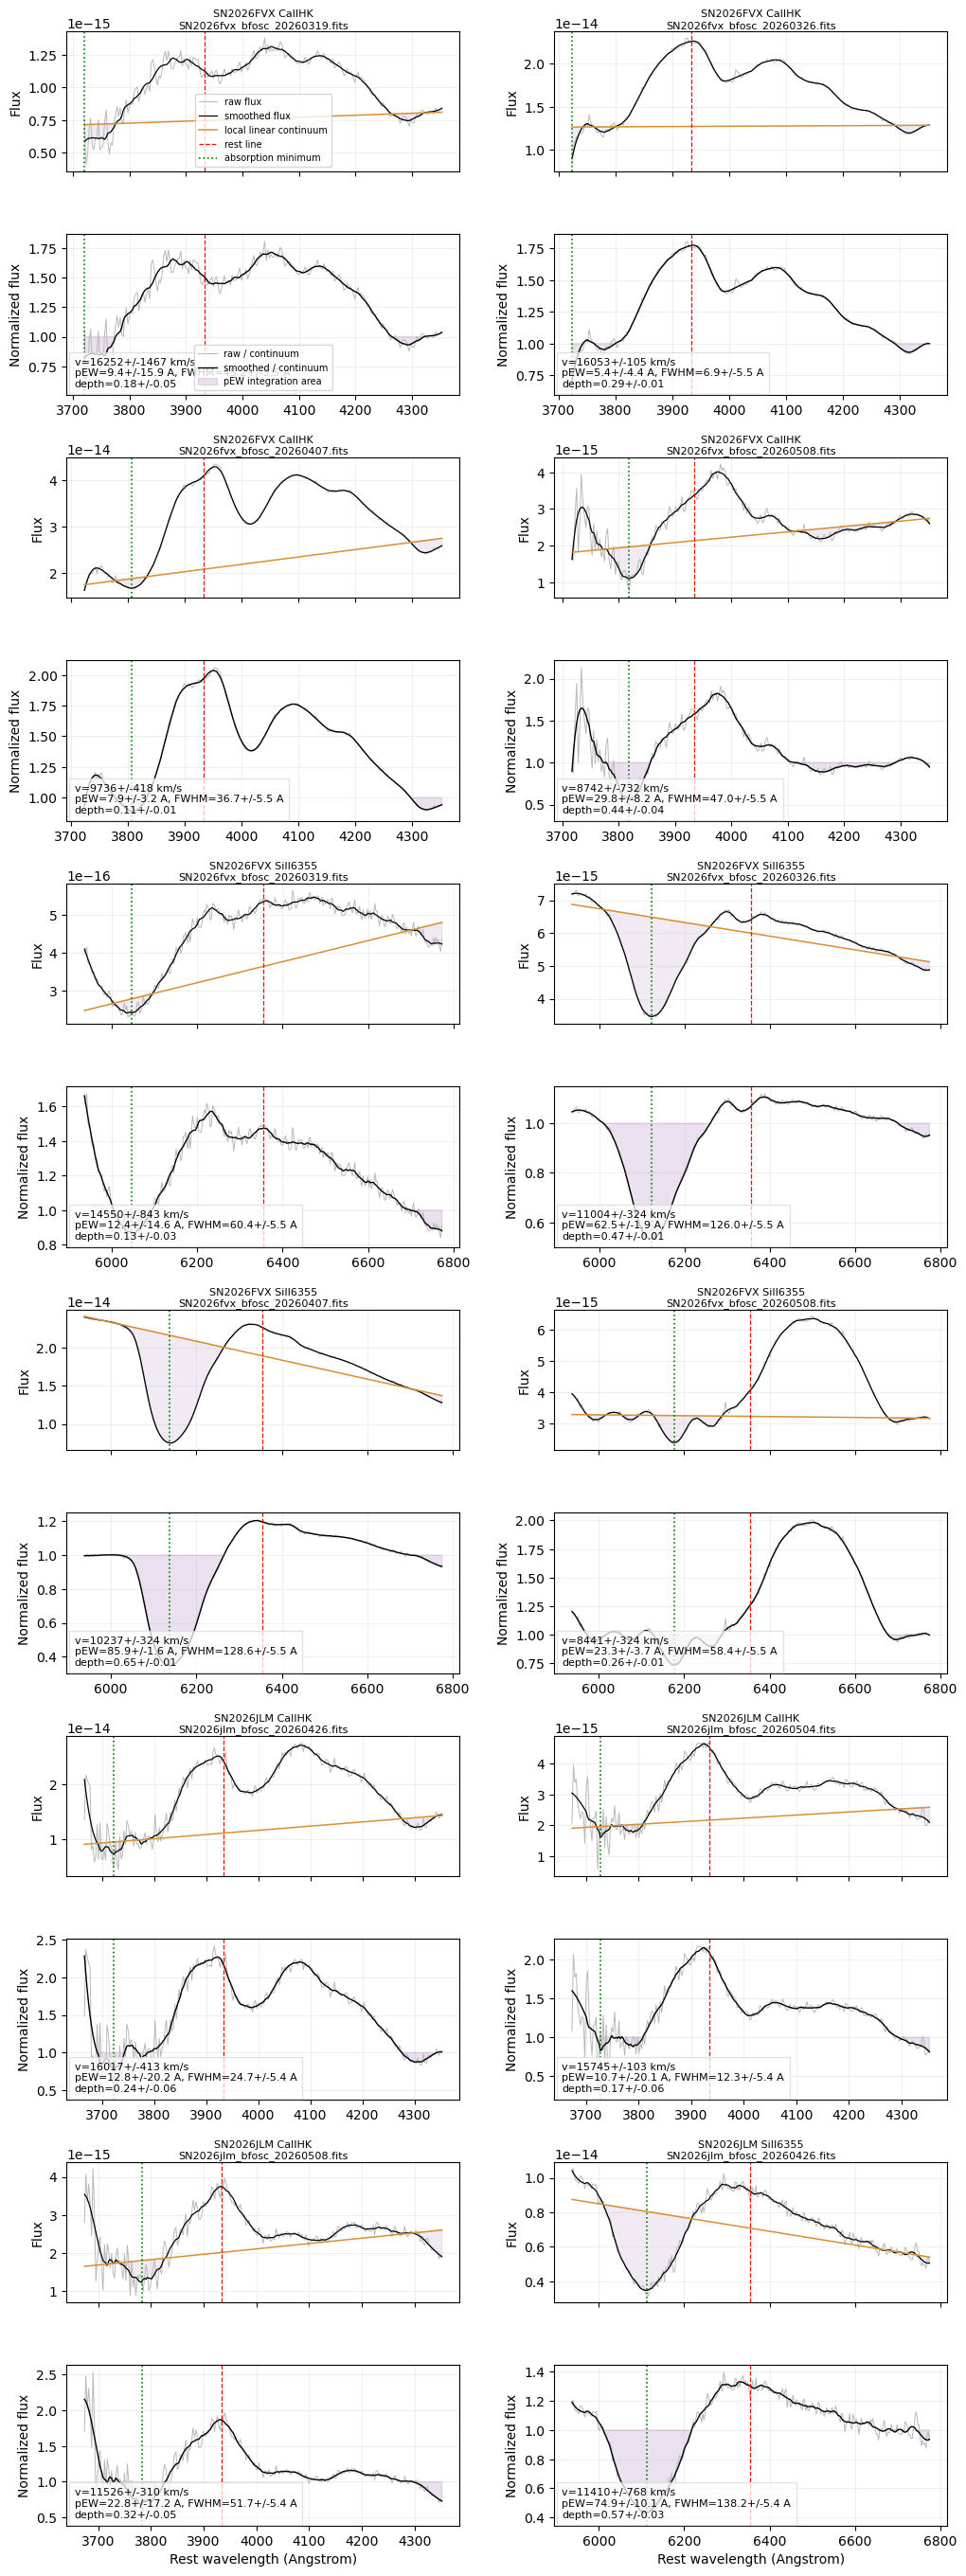

In [8]:
line_diagnostics_fig = snt.plot_line_diagnostics_grid(
    spectra,
    line_qc,
    target=DIAGNOSTIC_TARGET,
    max_panels=MAX_DIAGNOSTIC_PANELS,
    fig_dir=FIG_DIR,
    save_figures=SAVE_FIGURES,
    filename_tag=RUN_TAG,
    **measure_kwargs,
)
snt.show_figure(line_diagnostics_fig)

## 8. 黑体连续谱拟合图

方法说明：先取 `BB_WAVE_RANGE` 内的静止系光谱，平滑后做简单背景偏移和归一化，再用 Planck `B_lambda(T)` 黑体谱作非线性最小二乘拟合；输出的是颜色温度 proxy，不是完整辐射传输温度。非 Ia 或缺红移目标即使拟合成功也会被标为 `T_qc_flag=check`。图的标题分两行显示，只有最底行显示横坐标标题，避免标题与横坐标重叠。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_blackbody_fit_grid.png


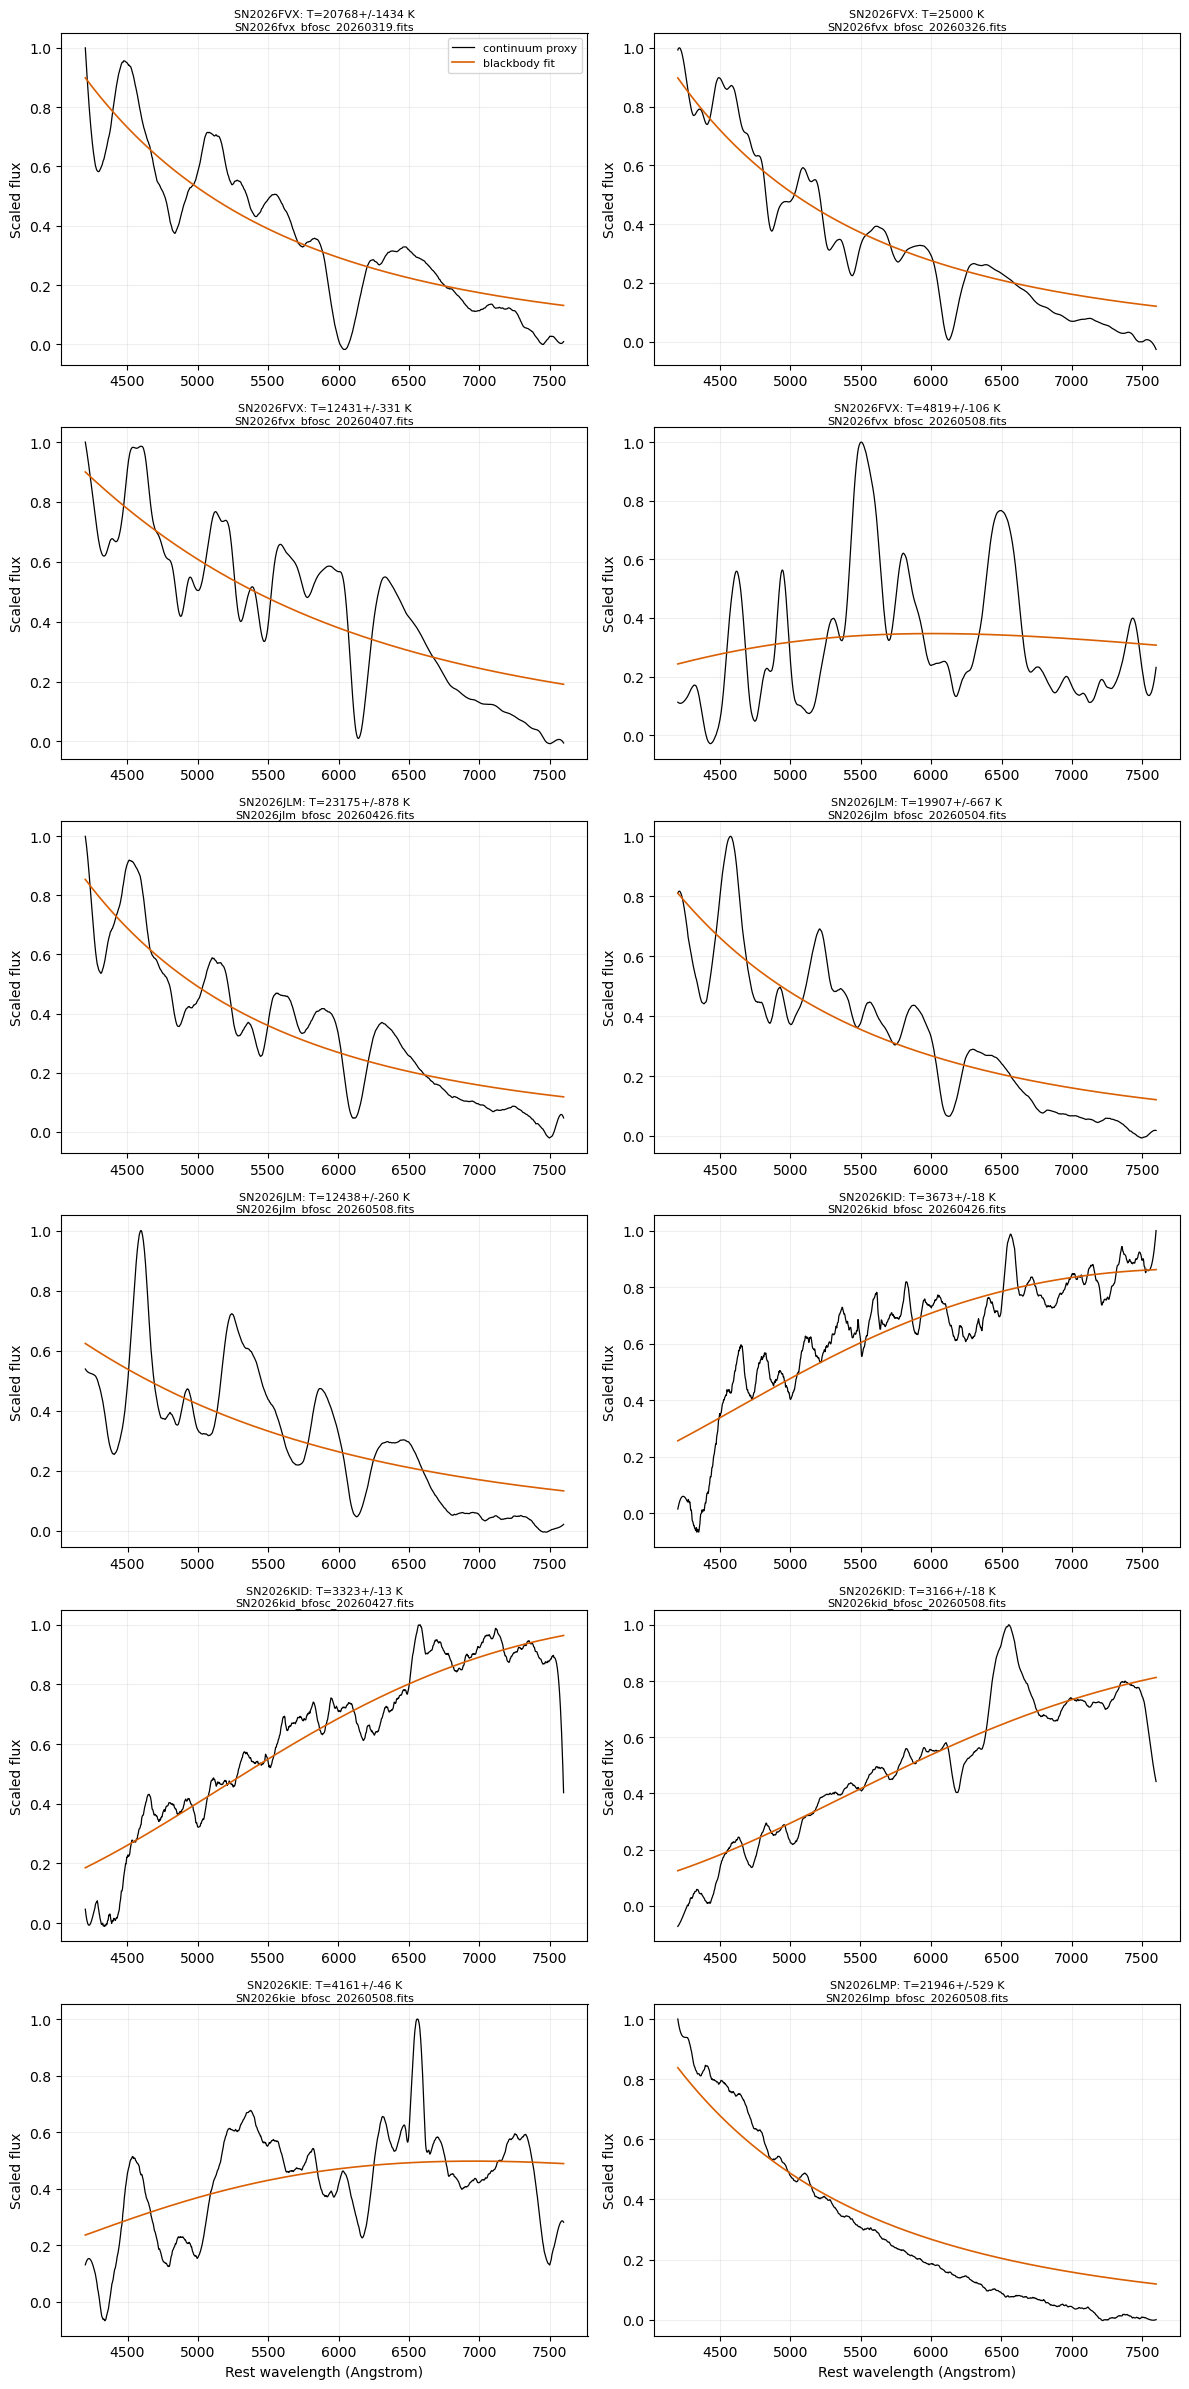

In [9]:
blackbody_fit_fig = snt.plot_blackbody_fit_grid(
    spectra,
    target=DIAGNOSTIC_TARGET,
    wave_range=BB_WAVE_RANGE,
    fig_dir=FIG_DIR,
    save_figures=SAVE_FIGURES,
    filename_tag=RUN_TAG,
)
snt.show_figure(blackbody_fit_fig)

## 9. 科学量图：谱线速度

方法说明：本步只绘制第 6 节已经测出的速度，不再做新拟合。误差棒使用 `velocity_err_kms`，即 `fit_center_err_A` 经过 `c / rest_wave` 传播后的 1-sigma 误差；误差列缺失、非有限或不大于 0 的点不会画误差棒。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_line_velocity_evolution.png


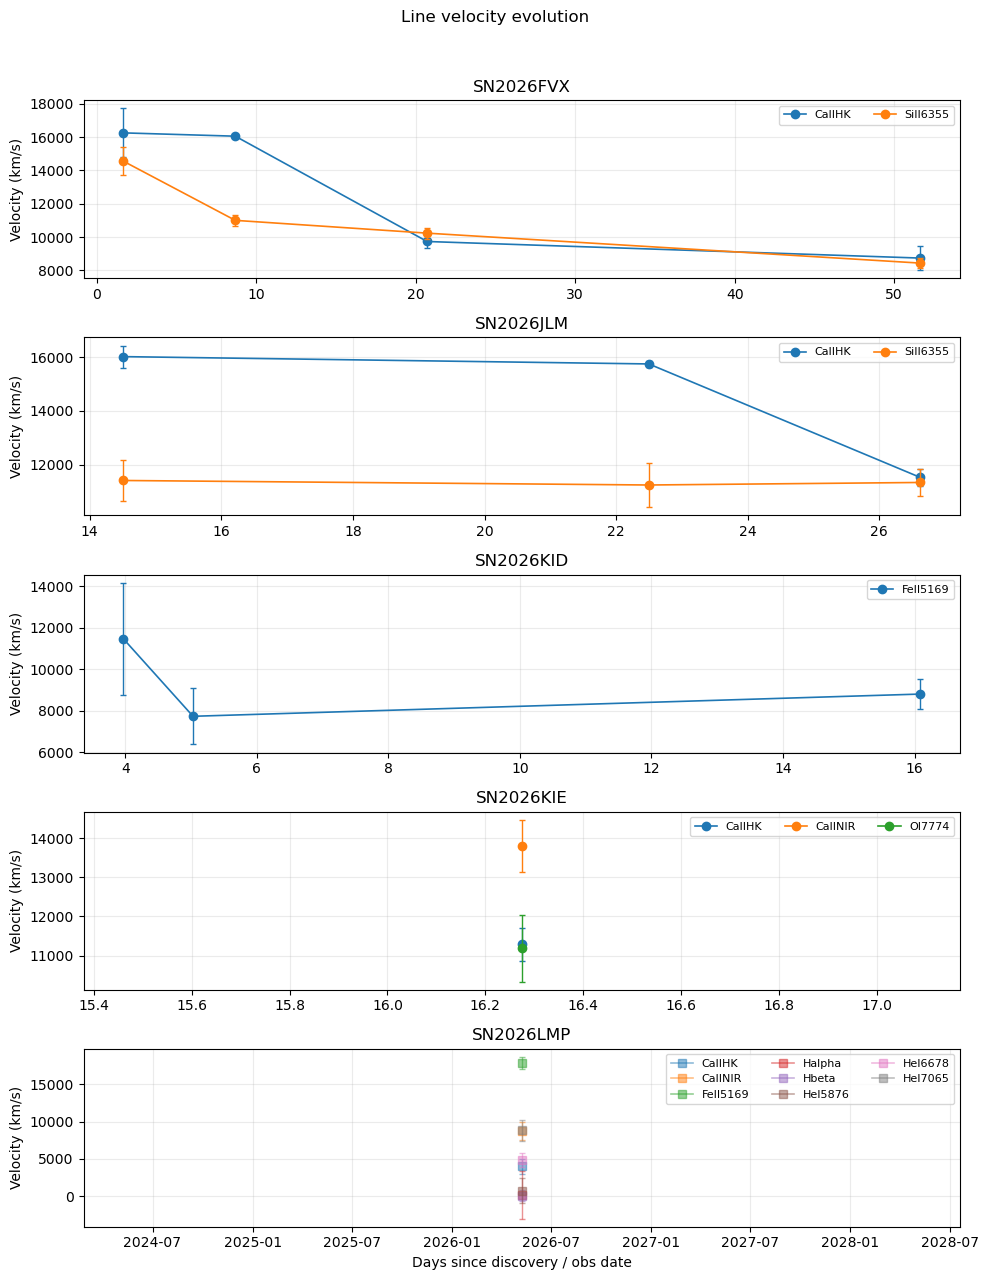

In [10]:
velocity_fig = snt.plot_quantity_by_target(line_qc, "velocity_kms", "Velocity (km/s)", "Line velocity evolution", snt.tagged_filename("line_velocity_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(velocity_fig)

## 10. 科学量图：pseudo-equivalent width

方法说明：本步只绘制第 6 节由局部线性连续谱归一化后积分得到的 pEW，不再做新拟合。误差棒使用 `pEW_err_A`，来自局部归一化残差噪声在吸收积分区间内的传播；它不包含完整连续谱系统误差。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_pew_evolution.png


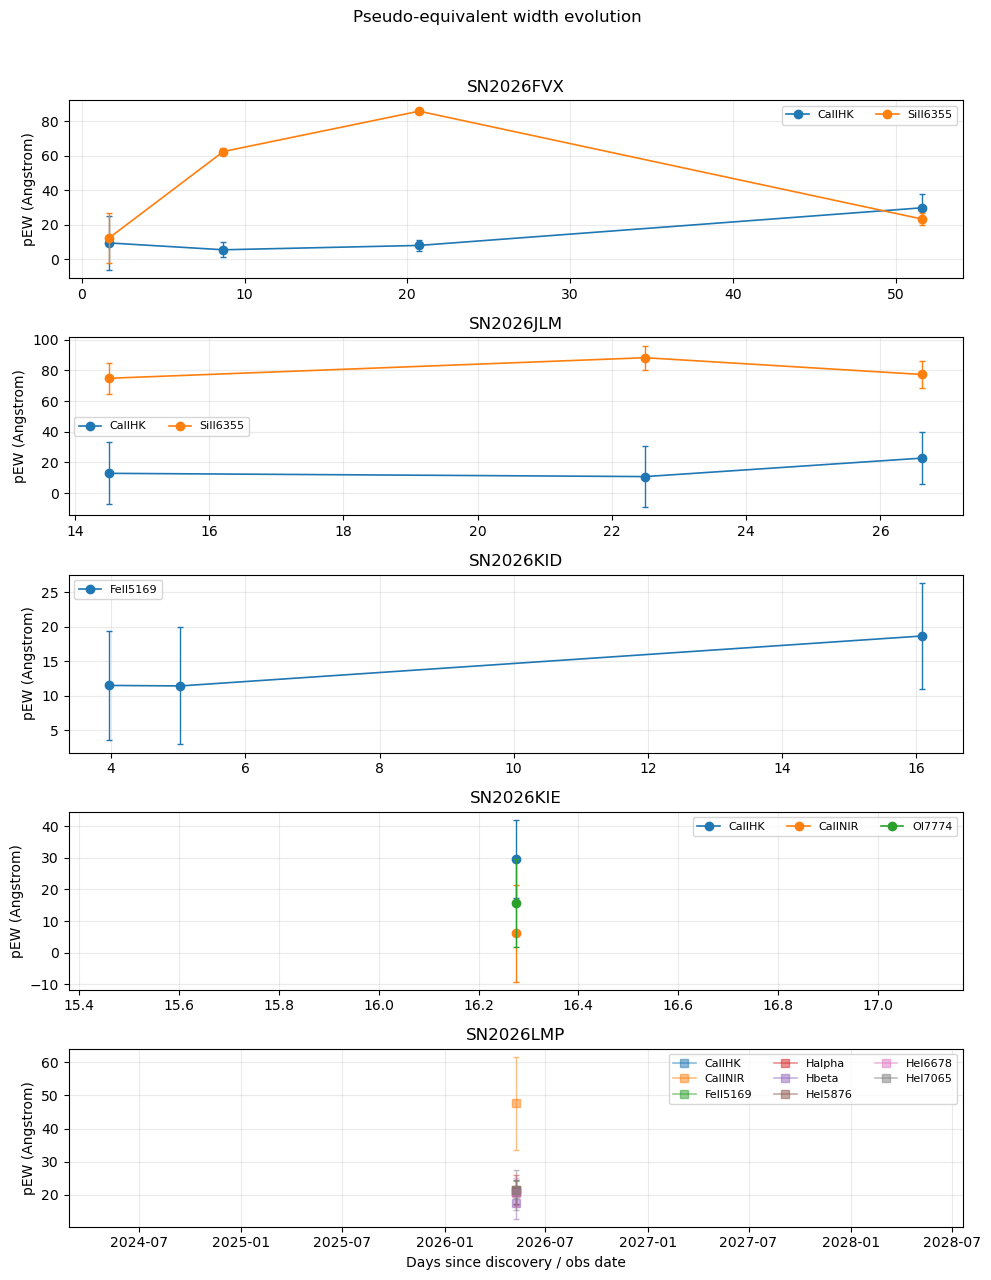

In [11]:
pew_fig = snt.plot_quantity_by_target(line_qc, "pEW_A", "pEW (Angstrom)", "Pseudo-equivalent width evolution", snt.tagged_filename("pew_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(pew_fig)

## 11. 科学量图：FWHM

方法说明：本步只绘制第 6 节得到的非参数半深度宽度，不再做新测量。误差棒使用 `FWHM_err_A`；如果吸收谷一侧半深度交点找不到、被窗口边界截断，或局部波长采样不足，就不会显示误差棒。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_fwhm_evolution.png


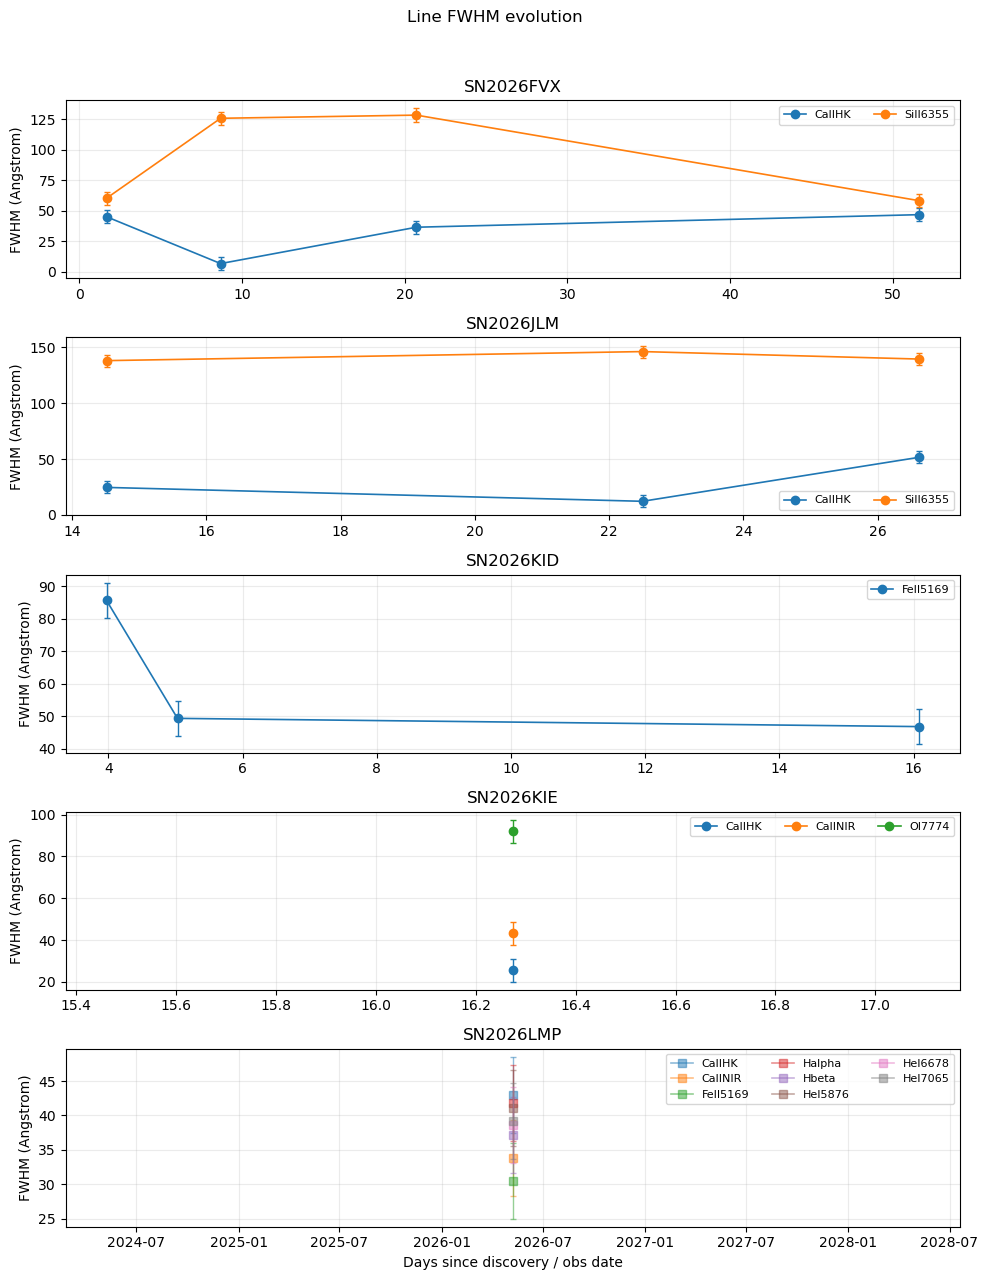

In [12]:
fwhm_fig = snt.plot_quantity_by_target(line_qc, "FWHM_A", "FWHM (Angstrom)", "Line FWHM evolution", snt.tagged_filename("fwhm_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(fwhm_fig)

## 12. 科学量图：线深

方法说明：本步只绘制第 6 节最低点得到的线深，不再做新测量。误差棒使用 `fit_depth_err`，来自局部归一化残差噪声尺度；如果噪声无法可靠估计或测量被 QC 标记，误差棒可能缺失。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_line_depth_evolution.png


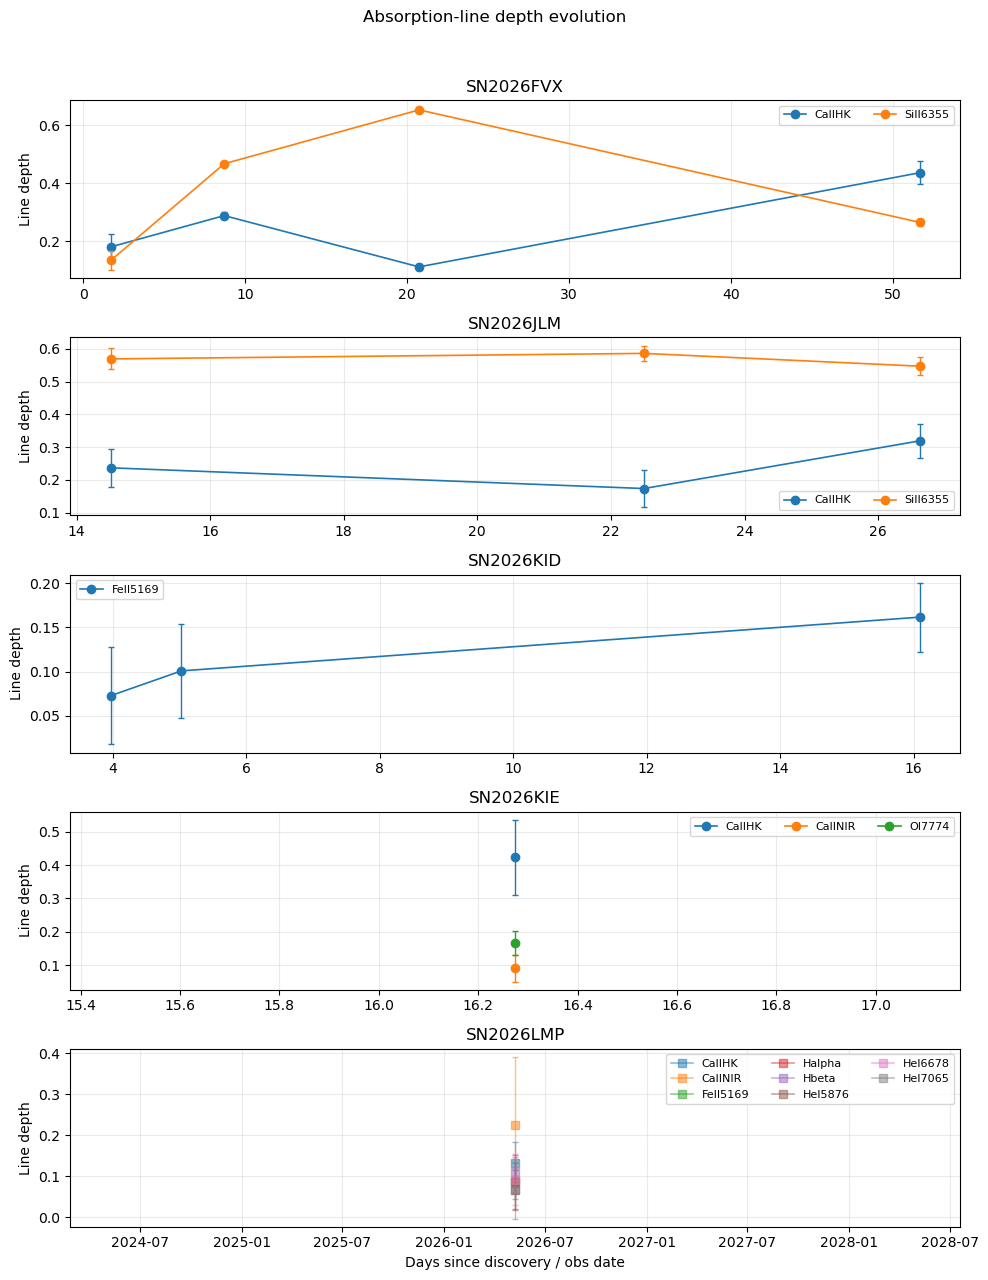

In [13]:
depth_fig = snt.plot_quantity_by_target(line_qc, "depth", "Line depth", "Absorption-line depth evolution", snt.tagged_filename("line_depth_evolution.png", RUN_TAG), FIG_DIR, save_figures=SAVE_FIGURES)
snt.show_figure(depth_fig)

## 13. 科学量图：连续谱黑体颜色温度

方法说明：本步只把第 6/8 节 Planck 黑体谱拟合得到的颜色温度画成演化图，不再做新拟合。误差棒使用 `T_err_K`，来自残差 bootstrap 的 16/84 分位差半宽；温度贴边、bootstrap 有效样本不足、非 Ia 或缺红移时不应作为物理温度引用。这里的横轴仍是距发现日天数。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_blackbody_temperature.png


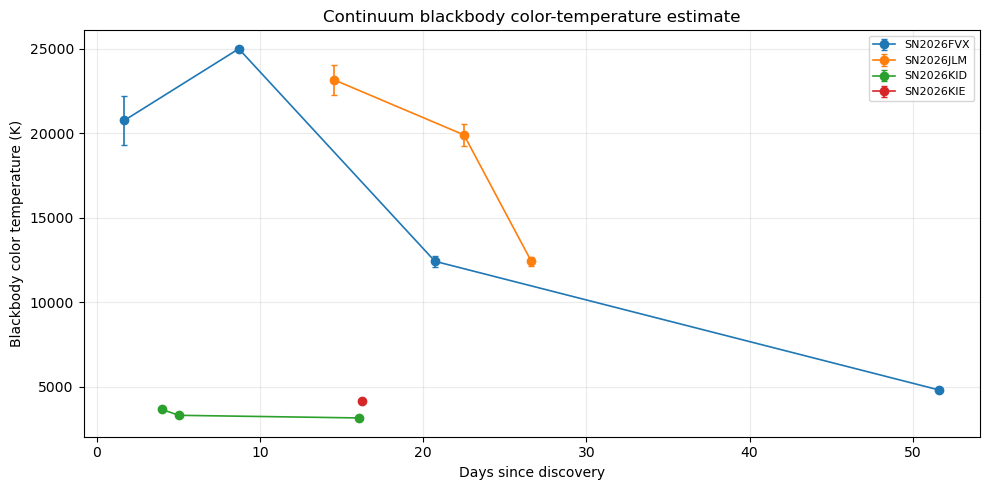

,target,file,date_obs,phase_days,type,z,T_bb_K,T_err_K,T_qc_flag,T_qc_note,T_err_method,T_err_n_bootstrap,status
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,20767.636478,1434.329437,adopt,residual bootstrap uncertainty,residual_bootstrap,80,ok
1,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260326.fits,2026-03-26 16:21:28,8.695464,SN Ia,0.004846,24999.997734,NaN,check,temperature hit fit boundary,residual_bootstrap,80,ok
2,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260407.fits,2026-04-07 16:57:15,20.720314,SN Ia,0.004846,12431.024275,330.657136,adopt,residual bootstrap uncertainty,residual_bootstrap,80,ok
3,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260508.fits,2026-05-08 14:38:31,51.623971,SN Ia,0.004846,4819.019015,105.630158,adopt,residual bootstrap uncertainty,residual_bootstrap,80,ok
4,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260426.fits,2026-04-26 12:52:13,14.511922,SN Ia,0.016738,23174.581605,878.286861,adopt,residual bootstrap uncertainty,residual_bootstrap,80,ok
5,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260504.fits,2026-05-04 12:29:41,22.496273,SN Ia,0.016738,19907.386396,667.255648,adopt,residual bootstrap uncertainty,residual_bootstrap,80,ok
6,SN2026JLM,data/SN2026jlm/SN2026jlm_bfosc_20260508.fits,2026-05-08 15:28:02,26.620128,SN Ia,0.016738,12437.570030,259.589858,adopt,residual bootstrap uncertainty,residual_bootstrap,80,ok
7,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260426.fits,2026-04-26 13:42:30,3.971331,SN II,0.001700,3672.848557,18.115729,check,residual bootstrap uncertainty; non-Ia continu...,residual_bootstrap,80,ok
8,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260427.fits,2026-04-27 15:05:27,5.028935,SN II,0.001700,3322.529026,12.732052,check,residual bootstrap uncertainty; non-Ia continu...,residual_bootstrap,80,ok
9,SN2026KID,data/SN2026kid/SN2026kid_bfosc_20260508.fits,2026-05-08 16:27:20,16.085799,SN II,0.001700,3166.386173,17.561525,check,residual bootstrap uncertainty; non-Ia continu...,residual_bootstrap,80,ok


In [14]:
ok_bb = bb_df[bb_df["status"].eq("ok")].copy()
if ok_bb.empty:
    print("没有成功的黑体颜色温度拟合。")
else:
    ok_bb["phase_days"] = pd.to_numeric(ok_bb.get("phase_days", pd.Series(dtype=float)), errors="coerce")
    phased_bb = ok_bb[ok_bb["phase_days"].notna()].copy()
    use_phase_axis = not phased_bb.empty
    plot_bb = phased_bb if use_phase_axis else ok_bb.copy()
    if not use_phase_axis:
        plot_bb["date_obs"] = pd.to_datetime(plot_bb.get("date_obs", pd.Series(dtype=object)), errors="coerce")
        plot_bb = plot_bb[plot_bb["date_obs"].notna()].copy()
    if plot_bb.empty:
        print("黑体颜色温度拟合缺少可画的 phase_days/date_obs。")
    fig, ax = plt.subplots(figsize=(10, 5))
    for target, group in plot_bb.groupby("target"):
        group = group.sort_values("phase_days" if use_phase_axis else "date_obs")
        x = group["phase_days"] if use_phase_axis else group["date_obs"]
        yerr = pd.to_numeric(group["T_err_K"], errors="coerce")
        yerr = yerr.where(np.isfinite(yerr) & (yerr > 0))
        ax.errorbar(
            x,
            group["T_bb_K"],
            yerr=yerr if yerr.notna().any() else None,
            marker="o",
            capsize=2,
            lw=1.2,
            label=target,
        )
    ax.set_ylabel("Blackbody color temperature (K)")
    ax.set_xlabel("Days since discovery" if use_phase_axis else "Observation date")
    ax.set_title("Continuum blackbody color-temperature estimate")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    snt.save_figure(fig, FIG_DIR, snt.tagged_filename("blackbody_temperature.png", RUN_TAG), enabled=SAVE_FIGURES)
    snt.show_figure(fig)
display(bb_df)

## 14. 科学量图：宿主/环境窄线指标

方法说明：宿主线指标使用红移后的窄窗口，局部两侧窗口取中位数连续谱，用 MAD/标准差估计噪声，并积分线区通量；这里不做轮廓模型拟合，也不能替代严格流量定标的环境诊断。当前图主要看 `snr` 和线指数强弱，不画物理通量误差棒。summary 表同时包含 detected row 数和唯一 detected line 数；写报告时优先使用 `unique_detected_host_lines`。


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/final5_host_line_detections.png


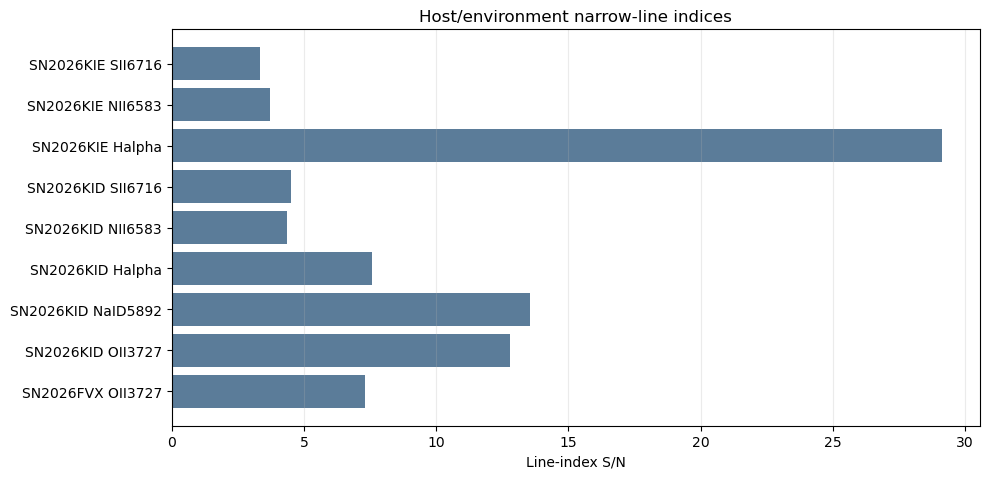

,target,n_detected_host_lines,n_detected_host_line_instances,unique_detected_host_lines,detected_lines,balmer_decrement_Ha_Hb,rough_EBV_host_mag,host_note
0,SN2026FVX,1,1,1,OII3727,NaN,NaN,rough index from SN spectra; verify before phy...
1,SN2026JLM,0,0,0,,NaN,NaN,rough index from SN spectra; verify before phy...
2,SN2026KID,10,10,5,"Halpha, NII6583, NaID5892, OII3727, SII6716",NaN,NaN,rough index from SN spectra; verify before phy...
3,SN2026KIE,3,3,3,"Halpha, NII6583, SII6716",NaN,NaN,rough index from SN spectra; verify before phy...
4,SN2026LMP,0,0,0,,NaN,NaN,rough index from SN spectra; verify before phy...


,target,file,date_obs,phase_days,type,z,line,rest_wave,status,snr,flux_index,pEW_A
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,OII3727,3727.0,weak/non-detection,0.210734,-6.510083e-16,0.018742
1,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,Hbeta,4861.3,weak/non-detection,-0.048108,-8.591856e-17,0.000000
2,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,OIII4959,4958.9,weak/non-detection,0.492749,1.871410e-16,0.259801
3,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,OIII5007,5006.8,weak/non-detection,-0.047383,-2.468585e-16,0.000000
4,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,NaID5892,5892.0,weak/non-detection,1.094613,-4.739679e-16,0.861409


In [15]:
host_line_fig = snt.plot_host_line_grid(host_lines, target=DIAGNOSTIC_TARGET, fig_dir=FIG_DIR, save_figures=SAVE_FIGURES, filename_tag=RUN_TAG)
snt.show_figure(host_line_fig)
display(host_summary)
display(host_lines.head(5))

## 15. 单条谱线局部检查图

改 `CHECK_TARGET`、`CHECK_SPECTRUM_INDEX`、`CHECK_LINE_KEY`，或回到配置区改 `LINE_PARAM_OVERRIDES`、`CHECK_HALF_WIDTH`、`CHECK_SMOOTH_WINDOW`、`CHECK_EDGE_FRACTION` 后重新运行。

图中算法说明：

- 先从当前选中的一维 FITS 光谱中，取 `line_check_options()` 给出的可选关键线表。
- `CHECK_LINE_KEY` 为空时，用 `CHECK_LINE_INDEX` 选择第几条候选线；表格里 `line_index` 已经按 adopt、check、自动候选的优先级排序。
- 局部窗口先把观测波长按 `wave_rest = wave_obs / (1 + z)` 转到静止系，再用 Savitzky-Golay 做预平滑。
- 连续谱用窗口两端的中位数连成局部线性连续谱，之后用 `norm = smooth_flux / continuum` 做归一化。
- 吸收中心直接取搜索窗口内归一化谱的最低点：`abs_wave = lambda_min`。
- 速度用 `velocity_kms = c * (rest_wave - abs_wave) / rest_wave`；线深用 `depth = 1 - norm_min`。
- `FWHM_A` 是最低点两侧半深度水平 `1 - depth / 2` 的线性交点宽度，不由解析轮廓参数换算。
- `pEW_A` 是 `clip(1 - norm, 0, None)` 在局部窗口内的直接积分。
- 误差同第 6 节：`velocity_err_kms = c * fit_center_err_A / rest_wave`，`FWHM_err_A` 来自半深度交点附近的波长采样，`fit_depth_err` 来自局部归一化残差噪声，`pEW_err_A` 来自局部归一化残差噪声在吸收积分区间内的传播。
- `CHECK_*` 里的临时改动只影响这张预览图；如果要固化为正式结果，请把对应参数写回 `LINE_PARAM_OVERRIDES` 并重新跑第 6 节。

这张图只负责手动检查和临时调参，不再承载主流程红移估计功能。


,spectrum_index,target,date_obs,file,z,type
0,0,SN2026FVX,2026-03-19 16:08:15,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,0.004846,SN Ia
1,1,SN2026FVX,2026-03-26 16:21:28,data/SN2026fvx/SN2026fvx_bfosc_20260326.fits,0.004846,SN Ia
2,2,SN2026FVX,2026-04-07 16:57:15,data/SN2026fvx/SN2026fvx_bfosc_20260407.fits,0.004846,SN Ia
3,3,SN2026FVX,2026-05-08 14:38:31,data/SN2026fvx/SN2026fvx_bfosc_20260508.fits,0.004846,SN Ia


,line_index,line,line_label,rest_wave,qc_flag,status,velocity_kms,velocity_err_kms,pEW_A,pEW_err_A,FWHM_A,FWHM_err_A,qc_note
0,0,CaIIHK,Ca II H&K / K,3933.7,adopt,ok,16252.013550,1466.831662,9.38237,15.872907,45.247747,5.499115,primary line with conservative automatic check...
1,1,SiII6355,Si II 6355,6355.0,adopt,ok,14549.671132,843.104240,12.37379,14.598442,60.427568,5.499115,primary line with conservative automatic check...


可调关键线:
  [0] CaIIHK (Ca II H&K / K)
  [1] SiII6355 (Si II 6355)
line check target=SN2026FVX, spectrum_index=0, line=SiII6355
selected CHECK_LINE_INDEX=1
file = data/SN2026fvx/SN2026fvx_bfosc_20260319.fits
z = 0.004846 (tns_public_catalog)
preview overrides: half_width=420.0, smooth_window=21, edge_fraction=0.18


saved /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/figures/line_check_SN2026FVX_SN2026fvx_bfosc_20260319_SiII6355.png


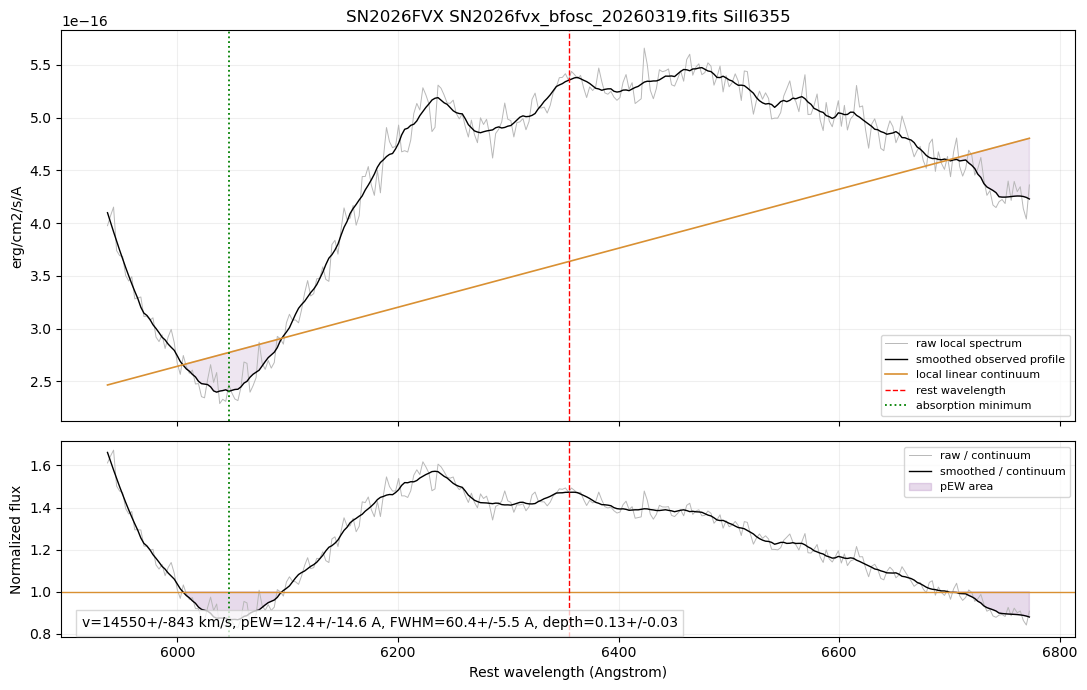

,target,file,date_obs,phase_days,type,z,line,line_label,rest_wave,rest_wave_choice,...,n_systematic_variants,depth,fit_center_err_A,fit_sigma_A,fit_sigma_err_A,fit_depth_err,fit_chi2_red,extrema_wave_A,extrema_depth,status
0,SN2026FVX,data/SN2026fvx/SN2026fvx_bfosc_20260319.fits,2026-03-19 16:08:15,1.686286,SN Ia,0.004846,SiII6355,Si II 6355,6355.0,single_line,...,4,0.132808,17.872122,NaN,NaN,0.033783,NaN,6046.576097,0.132808,ok


In [16]:
# Force fresh measurement/plotting code; stale notebook kernels can keep older helper definitions.
sp = reload(sp)
snt = reload(snt)

CHECK_TARGET = None
CHECK_SPECTRUM_INDEX = 0  # 选第几条光谱
CHECK_LINE_KEY = None  # 为空时启用 CHECK_LINE_INDEX
CHECK_LINE_INDEX = 3  # CHECK_LINE_KEY=None 时选择第几条候选线
CHECK_HALF_WIDTH = None
CHECK_SMOOTH_WINDOW = None
CHECK_EDGE_FRACTION = None

CHECK_TARGET_LOCAL = summary.iloc[0]["target"] if CHECK_TARGET is None else CHECK_TARGET
check_spec_table = snt.spectrum_choice_table(spectra, CHECK_TARGET_LOCAL)
display(check_spec_table)

check_items = sorted(
    [spec for spec in spectra if spec["target"] == snt.target_key(CHECK_TARGET_LOCAL)],
    key=lambda spec: pd.Timestamp.max if pd.isna(spec["date_obs"]) else spec["date_obs"],
)
if not check_items:
    raise RuntimeError(f"No spectra found for CHECK_TARGET={CHECK_TARGET_LOCAL}")

selected_spectrum_index = int(np.clip(int(CHECK_SPECTRUM_INDEX), 0, len(check_items) - 1))
check_spec = check_items[selected_spectrum_index]

line_options = snt.line_check_options(
    spectra,
    line_qc,
    CHECK_TARGET_LOCAL,
    selected_spectrum_index,
    TARGET_LINES,
)
if line_options.empty:
    raise RuntimeError("当前目标没有可供局部检查的关键线。请检查 TARGET_LINES、line_qc 或谱线类型。")

display(line_options)
print("可调关键线:")
for _, row in line_options.iterrows():
    print(f"  [{int(row['line_index'])}] {row['line']} ({row['line_label']})")

explicit_line_key = None if CHECK_LINE_KEY is None else str(CHECK_LINE_KEY).strip()
if explicit_line_key:
    if explicit_line_key not in sp.LINE_LIBRARY:
        known = ", ".join(sorted(sp.LINE_LIBRARY))
        raise KeyError(f"Unknown CHECK_LINE_KEY={explicit_line_key!r}. Known line keys: {known}")
    selected_line_key = explicit_line_key
    selected_line_index = None
else:
    selected_line_index = int(np.clip(int(CHECK_LINE_INDEX), 0, len(line_options) - 1))
    selected_line_key = str(line_options.iloc[selected_line_index]["line"])

print(
    f"line check target={snt.target_key(CHECK_TARGET_LOCAL)}, "
    f"spectrum_index={selected_spectrum_index}, "
    f"line={selected_line_key}"
)
if selected_line_index is not None:
    print(f"selected CHECK_LINE_INDEX={selected_line_index}")
print(f"file = {check_spec['file']}")
print(f"z = {check_spec.get('z')} ({check_spec.get('z_source')})")

check_measure_kwargs = dict(measure_kwargs)
if CHECK_HALF_WIDTH is not None:
    check_measure_kwargs["line_half_width"] = float(CHECK_HALF_WIDTH)
if CHECK_SMOOTH_WINDOW is not None:
    check_measure_kwargs["line_smooth_window"] = int(CHECK_SMOOTH_WINDOW)
if CHECK_EDGE_FRACTION is not None:
    check_measure_kwargs["line_edge_fraction"] = float(CHECK_EDGE_FRACTION)

print(
    "preview overrides: "
    f"half_width={check_measure_kwargs['line_half_width']}, "
    f"smooth_window={check_measure_kwargs['line_smooth_window']}, "
    f"edge_fraction={check_measure_kwargs['line_edge_fraction']}"
)

check_result, check_fig = snt.plot_line_check(
    spectra,
    target=CHECK_TARGET_LOCAL,
    line_key=selected_line_key,
    spectrum_index=selected_spectrum_index,
    fig_dir=FIG_DIR,
    save_figures=SAVE_FIGURES,
    **check_measure_kwargs,
)
snt.show_figure(check_fig)
display(check_result)


## 16. 保存 CSV 汇总

方法说明：本节只把前面已经算出的表格写入 CSV，不运行新的拟合或重新测量。输出文件会使用 `RUN_TAG`，例如 `SN2026KID_line_diagnostics_qc.csv`；同一目标重跑会覆盖同一目标文件，但不会覆盖其他目标。

In [17]:
def output_path(name):
    ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
    return snt.analysis_output_path(ANALYSIS_DIR, name, tag=RUN_TAG, product_prefix=PRODUCT_PREFIX)


if SAVE_PRODUCTS:
    outputs = {
        "spectra_summary": output_path("spectra_summary.csv"),
        "line_diagnostics_raw": output_path("line_diagnostics_raw.csv"),
        "line_diagnostics_qc": output_path("line_diagnostics_qc.csv"),
        "blackbody_temperature": output_path("blackbody_temperature.csv"),
        "host_environment_lines": output_path("host_environment_lines.csv"),
        "host_environment_summary": output_path("host_environment_summary.csv"),
        "target_status": output_path("target_status.csv"),
        "skipped_fits": output_path("skipped_fits.csv"),
    }
    summary.to_csv(outputs["spectra_summary"], index=False)
    line_df.to_csv(outputs["line_diagnostics_raw"], index=False)
    line_qc.to_csv(outputs["line_diagnostics_qc"], index=False)
    bb_df.to_csv(outputs["blackbody_temperature"], index=False)
    host_lines.to_csv(outputs["host_environment_lines"], index=False)
    host_summary.to_csv(outputs["host_environment_summary"], index=False)
    target_status.to_csv(outputs["target_status"], index=False)
    skipped_fits.to_csv(outputs["skipped_fits"], index=False)
    for label, path in outputs.items():
        print(f"{label}: {path}")
else:
    print("SAVE_PRODUCTS=False，未写出 CSV。")

spectra_summary: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_spectra_summary.csv
line_diagnostics_raw: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_line_diagnostics_raw.csv
line_diagnostics_qc: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_line_diagnostics_qc.csv
blackbody_temperature: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_blackbody_temperature.csv
host_environment_lines: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_host_environment_lines.csv
host_environment_summary: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_host_environment_summary.csv
target_status: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_target_status.csv
skipped_fits: /home/zzzaurak/THU/astro/obsastro-sn-pipeline/output/analysis_pipeline/final5_skipped_fits.csv


## 17. 下一步人工确认

方法说明：本节不做新测量，只列出需要人工检查和后续采用的结果。

正式报告里建议只引用：

1. TNS public catalog 的 adopted redshift（本 notebook 的默认红移来源）；
2. 距发现日天数 `phase_days`，不要写成最大光相位；
3. `qc_flag=adopt` 的自动测量；
4. 或者经过上面局部检查图确认后的 `qc_flag=check` 测量。

如果某条线的最低点落到错误吸收谷，优先在配置区用 `LINE_PARAM_OVERRIDES` 调整 `half_width`、`smooth_window`、`edge_fraction`，然后重新运行批量测量之后的 cells。

`CHECK_HALF_WIDTH`、`CHECK_SMOOTH_WINDOW`、`CHECK_EDGE_FRACTION` 只作为预览调参；如果要固化为正式结果，请把同样参数写回 `LINE_PARAM_OVERRIDES` 并重新跑第 6 节。
